### Challenges in Langchain:
1. Statelessness of LangChain: It is designed to chain LLM calls and tools, but it does not maintain persistent state across steps. Its memory is limited to conversational context only.
2. State Handling & Event Driven Execution: A complex workflow might requires some events to resume, pause, change, etc the flow. For we need to store the data but langchain (Stateless) does not store those things these things needs to be done manually
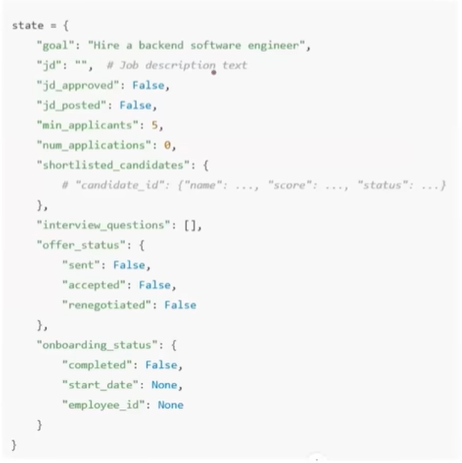

3. Fault Tolerance: In langchain if any step of a workflow gets failed, we need to restart the complete flow unless that case is hendles manually

4. Human In The Loop: Langchain does not have built in functionality to resume the workflow wait for the Human feedback & resume the flow (Possible for short duration, Not suitable for longer duration)

5. Nested Workflows: No built-in functionlity in Langchain

# LangGraph
- It is an orchestration framework that enables you to build stateful, multi-step, & event-driven workflows using LLM.
- It is ideal for designing single & multi-agent agentic AI application.
- Think of LangGrapg as a flowchart engine for LLM.
- LangGraph takes care of state management, conditional branching, looping, pausing/resuming & fault recovery
- LangGraph is built on top of LangChain - it doesn't replace it.
- LangGraph handles workflow orchestration while langchain provides the building blocks for each step in that workflow.

# LangGraph Core Components:

### 1. LLM Workflows:
- LLM Workflows are step by step process using which we can build complex LLM Application.
- Each step in a workflow performs a distinct task - such as prompting, reasoning, tool calling, memory access, or decision-making.
- Workflow can be linear, branched or looped, allowing for complex behaviours like retries, multi-agent communication, or tool-augmentated reasoning.
- Common Workflows:
    1. Prompt Chaining: Breaking a big task into smaller sequential LLM steps, where the output of one becomes the input of the next.
    2. Routing: The system decides which path or model/tool to use based on the input.
    3. Parallelization: Running multiple LLM calls at the same time and combining results.
    4. Orchestrator Workers: One central “controller” LLM (or system) delegates tasks to multiple worker agents/tools.
    5. Evaluator Optimizer: One component generates output, another evaluates it, and the system improves iteratively.
      
    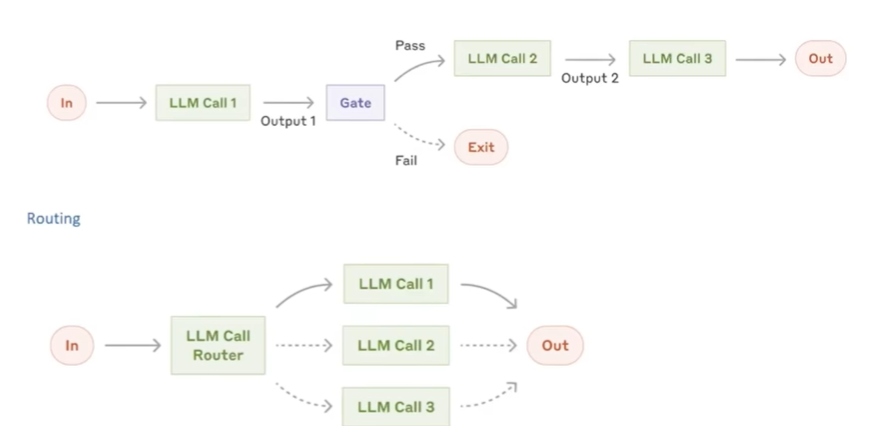
    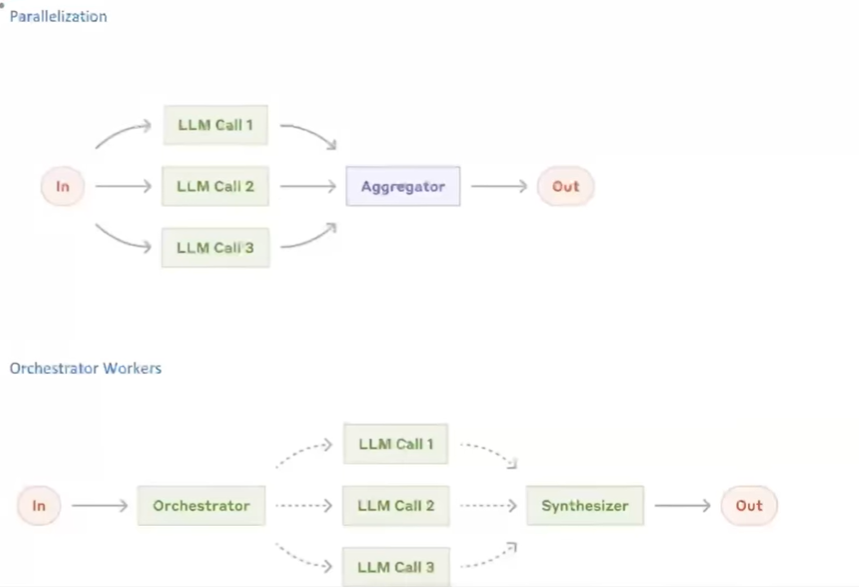
    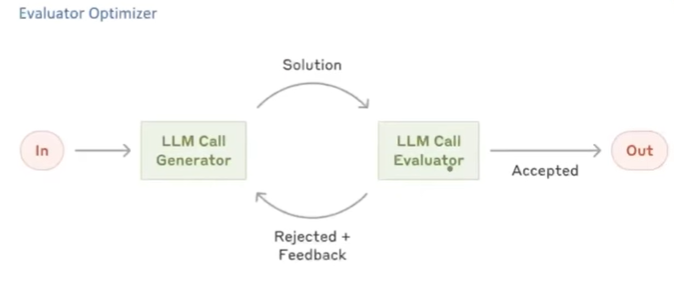

## 2. Graph, Nodes and Edges:
Let's create an application where UPSC Aspirants write their essays on a topic generated by the application & when they submit their essay our application evaluates their essays in different aspects & generates a score. If the score is >= threshold application will congratulate them else give them a feed & give option to them to write the essay again based on the feedback & evaluate again.  

The system generates an essay topic, collects the student's submission, & evaluates it in parallel on depth of analysis, language quality, & clarity of thought. Based on the combined score, it either gives feedback for improvement or approves the essay.  

### Problem Breakdown:
1. Generate Topic
2. Collect Essay
3. Evaluate Essay:
    - Evaluate Depth -> Analyze depth of analysis, arguement strength, & critical thinking
    - Evaluate Language -> Checks Grammar, vocabulary, fluency, & tone.
    - Evaluate Clarity -> Assesses coherence, logical flow, & clarity of thought.
4. Aggregate Result -> For generating score
5. Conditional Routing:
    - If score meets threshold -> Go to ShoeSuccess
    - If score is below threshold -> Go to GiveFeedBack
6. Give Feedback 
7. Collection Revised Essay (Optional Loop)
8. Show Success  
  
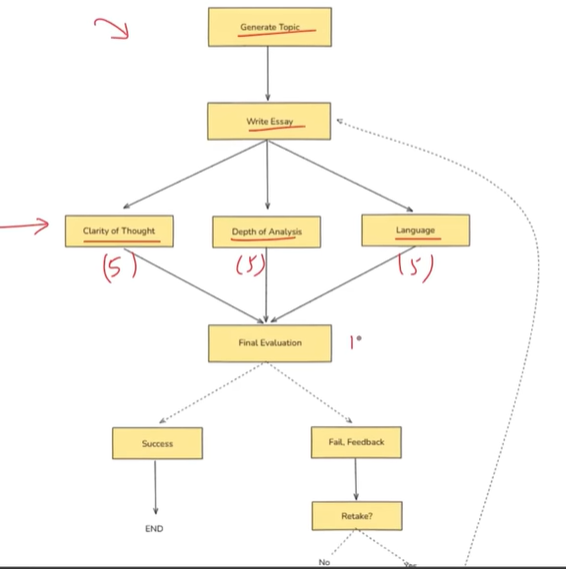

## 3. State
- In LangGraph, state is the shared memory that flows through your workflow - it holds all the data being passed b/w nodes & edges as your graph runs.
- For example, In the UPSC Essay evaluator flow there some data points which are require at multiple or later steps like "Write Essay" node data is requires is requited at Clarity of Thought, Depth of Analysis & Language nodes.  
  
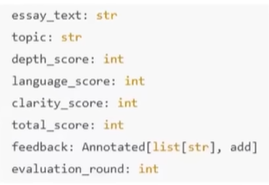
  
## 4. Reducers:
- Reducers in LangGraph define how updates from nodes are applied to the shared state.
- Each key in the state can have its own reducer, which determines whether new data replaces, merges, or adds to the existing value.

## LangGraph Execution Model
Intresting Fact: The LangGraph Execution Model is inspired with "Google Pregel" (System which can process graphs at a very large scale)  
  
### Graph Definition:
- You define:
    1. The State Schema
    2. Nodes (Functions that performs tasks)
    3. Edges (which node connect to which)

### Compilation:
- You call .comple() on the stateGraph
- This checks the graph structure & prepares it for execution

### Invocation:
- You run the graph with .invoke(initial_state)
- LangGraph sends the initial state as a message to the entry node(s)

### Super-Steps Begin:
- Execution proceeds in rounds
- In each roung:
    1. All active nodes (those that received messges) run in parallel
    2. Each return an update (message) to the state

### Message Passing & Node Activation:
- The messages are passed to downstream nodes via edges.
- Nodes that receive messages become active for the next round.

### Halting Condition:
- Execution stops when:
    1. No nodes are active, and
    2. No messages are in transit